In [1]:
%load_ext autotime

import scarf

scarf.__version__

'1.0.0'

time: 1.65 s (started: 2026-07-02 22:12:49 +02:00)


In [2]:
scarf.fetch_dataset(
    dataset_name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    save_path="./scarf_datasets",
    as_zarr=True,
)

time: 29.6 s (started: 2026-07-02 22:12:50 +02:00)


In [3]:
ds = scarf.DataStore(
    "scarf_datasets/bastidas-ponce_4K_pancreas-d15_rnaseq/data.zarr",
    nthreads=4,
    default_assay="RNA",
)

time: 344 ms (started: 2026-07-02 22:13:19 +02:00)


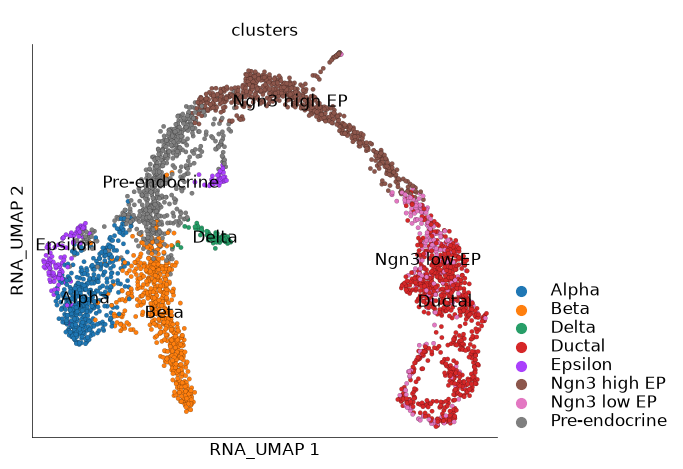

time: 1.23 s (started: 2026-07-02 22:13:19 +02:00)


In [4]:
ds.plot_layout(layout_key="RNA_UMAP", color_by="clusters")

In [5]:
ds.run_cell_cycle_scoring()

1 values were not found in the table column names



time: 1.94 s (started: 2026-07-02 22:13:21 +02:00)


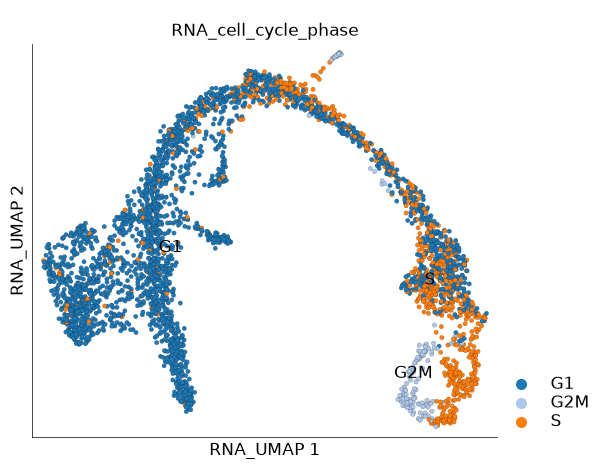

time: 411 ms (started: 2026-07-02 22:13:23 +02:00)


In [6]:
ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by="RNA_cell_cycle_phase",
    cmap="tab20",
)

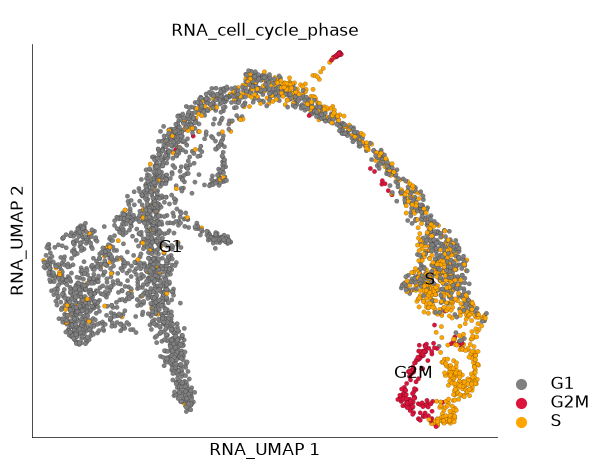

time: 402 ms (started: 2026-07-02 22:13:23 +02:00)


In [7]:
color_key = {
    "G1": "grey",
    "S": "orange",
    "G2M": "crimson",
}

ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by="RNA_cell_cycle_phase",
    color_key=color_key,
)

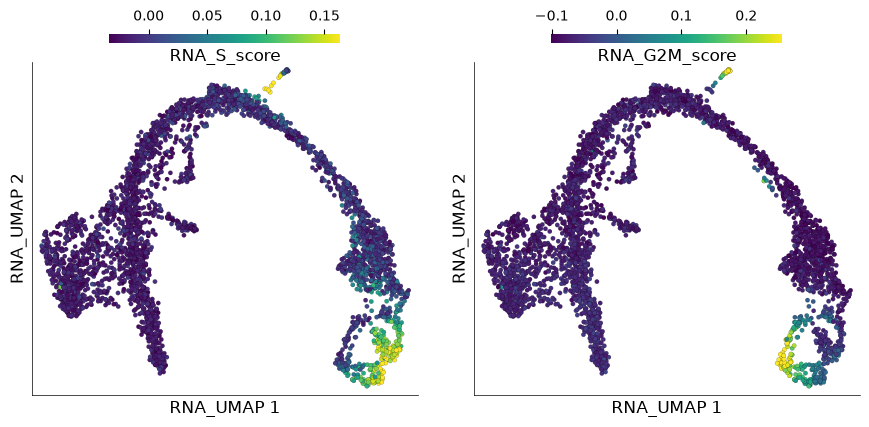

time: 893 ms (started: 2026-07-02 22:13:24 +02:00)


In [8]:
ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by=["RNA_S_score", "RNA_G2M_score"],
    width=4.5,
    height=4.5,
)

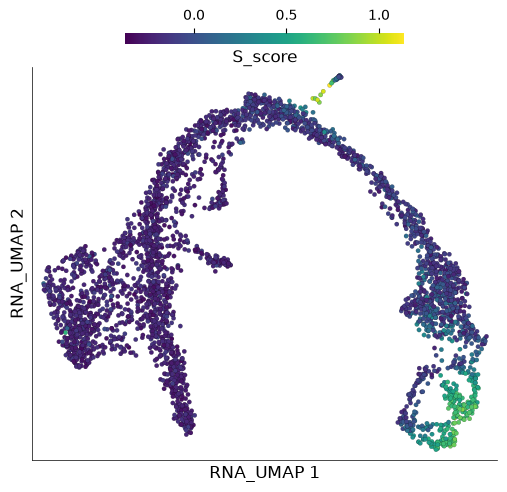

time: 546 ms (started: 2026-07-02 22:13:24 +02:00)


In [9]:
ds.plot_layout(
    layout_key="RNA_UMAP",
    color_by="S_score",
)

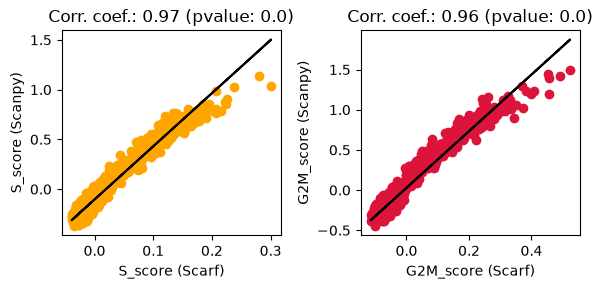

time: 567 ms (started: 2026-07-02 22:13:24 +02:00)


In [10]:
import matplotlib.pyplot as plt
from scipy.stats import linregress

fig, axis = plt.subplots(1, 2, figsize=(6, 3))
for n, i in enumerate(["S_score", "G2M_score"]):
    x = ds.cells.fetch(f"RNA_{i}")
    y = ds.cells.fetch(i)
    res = linregress(x, y)

    ax = axis[n]
    ax.scatter(x, y, color=color_key[i.split("_")[0]])
    ax.plot(x, res.intercept + res.slope * x, label="fitted line", c="k")
    ax.set_xlabel(f"{i} (Scarf)")
    ax.set_ylabel(f"{i} (Scanpy)")
    ax.set_title(f"Corr. coef.: {round(res.rvalue, 2)} (pvalue: {res.pvalue})")

plt.tight_layout()
plt.show()